# How Timeseries Aggregation works

Time-series aggregation (TSA) reduces the **temporal complexity** of a time series so a
downstream optimisation model can afford to solve over it. There are two broad ways to do
this: lower the **resolution** (fewer or coarser time steps over the same calendar), or
represent the series with a few **typical periods** (representative period-shapes carrying
occurrence weights). This overview starts from that general picture, narrows to tsam's
specific building blocks, and maps the rest of the series — every step of which is traced by
hand on a tiny six-day dataset (introduced in [Preprocessing](01_preprocessing.ipynb)).

## 1  The TSA taxonomy: two axes of common methods

Hoffmann et al. classifies common TSA methods along two independent axes that are shown in [Table 3](https://www.mdpi.com/1996-1073/13/3/641):

* **How** periods or timesteps are grouped — by **time position** (consecutive blocks,
  calendar position) or by **feature similarity** (grouping by value).
* **What the result is** — **resolution variation** (fewer/coarser timesteps, same calendar)
  or **typical periods** (a few representative period-shapes with occurrence weights).

|                   | **Resolution variation** | **Typical periods**          |
|-------------------|--------------------------|------------------------------|
| **Time-based**    | Downsampling             | Time slices / averaging      |
| **Feature-based** | Segmentation             | Clustering                   |

This maps the field, not tsam specifically. tsam focuses on the **feature-based column**
(clustering and segmentation) plus time-based block averaging.

*Methods that fall outside this 2×2 grid* are currently out of tsam's scope E.g.: shape- and time-shift-tolerant 
clustering (dynamic time warping, k-shape), dimensionality-reduction pre-processing (PCA, autoencoders),
multiple time grids per season, random period sampling, and full calendar time-slices(which need an external assignment
vector). Plain downsampling is a one-liner in pandas (`df.resample(rule).mean()`) and is
intentionally not duplicated.

## 2  How tsam decomposes the clustering step

Hoffmann et al. (2020) decompose feature-based time-series clustering into **five
fundamental aspects** — and tsam exposes each one as an independent choice:

> This means that time series clustering includes five fundamental aspects:
>
> - A normalization (and sometimes a dimensionality reduction).
> - A distance metric.
> - A clustering algorithm.
> - A method to choose representatives.
> - A rescaling step in the case of non-centroid based clustering algorithms.
>
> — Hoffmann et al. (2020), [§3.2.2 "Feature-Based Merging"](https://www.mdpi.com/1996-1073/13/3/641)

The consequence that shapes this guide: the **clustering algorithm** (which periods are
grouped together) and the **method to choose representatives** (how each group becomes one
profile) are *separate, recombinable* steps. Classical algorithms tie the two together —
k-means uses the mean, k-medoids the medoid — but the review notes for Ward agglomerative
clustering that "the cluster centers can either be represented by their centroids ... or by
their medoids." tsam takes this literally.

## 3  What tsam implements: grouping × representation

An aggregation in tsam is a short pipeline with **two choices** in the middle — any grouping
method paired with any representation method — followed by optional post-steps (dashed in the
diagram):

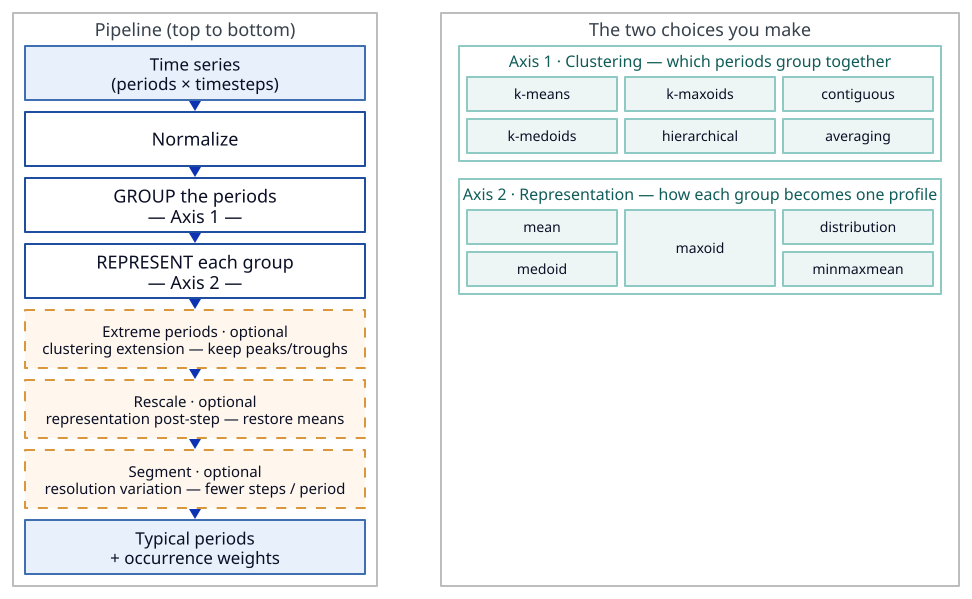

In [1]:
from IPython.display import SVG

# The two-axis pipeline, rendered from
# ../../assets/architecture/aggregation_methods.d2 — edit that file and run
# `d2 aggregation_methods.d2 aggregation_methods.svg` to regenerate.
SVG(filename="../../assets/architecture/aggregation_methods.svg")

**Axis 1 — Grouping (clustering) methods** *(which periods go together)*

| Clustering method | tsam name | Default representation | Notebook |
|---|---|---|---|
| k-means | `kmeans` | mean | [02](02_partitional_clustering.ipynb) |
| k-medoids | `kmedoids` | medoid | [02](02_partitional_clustering.ipynb) |
| k-maxoids | `kmaxoids` | maxoid | [02](02_partitional_clustering.ipynb) |
| Hierarchical Ward | `hierarchical` | medoid | [03](03_agglomerative_clustering.ipynb) |
| Contiguous Ward | `contiguous` | medoid | [03](03_agglomerative_clustering.ipynb) |
| Block averaging | `averaging` | mean | [04](04_averaging.ipynb) |

**Axis 2 — Representation methods** *(how each group becomes one profile)*

| Representation | tsam name | What it produces | Literature anchor | Notebook |
|---|---|---|---|---|
| Centroid | `mean` | per-timestep average of the group | k-means (classical) | [06](06_representation_rescaling.ipynb) |
| Medoid | `medoid` | the most central real period | k-medoids / PAM | [06](06_representation_rescaling.ipynb) |
| Maxoid | `maxoid` | the most extreme real period | tsam | [06](06_representation_rescaling.ipynb) |
| Distribution | `distribution` | values re-sorted to keep the duration curve | Kotzur 2018; review [18,140,149,150] | [06](06_representation_rescaling.ipynb) |
| Distribution + min/max | `distribution_minmax` | duration curve with per-column min/max preserved | shortcut for `Distribution(preserve_minmax=True)` | [06](06_representation_rescaling.ipynb) |
| Min/max + mean | `minmax_mean` | mean with per-column extremes preserved | extreme-preservation | [06](06_representation_rescaling.ipynb) |

**Optional post-steps** (dashed in the diagram, shown in pipeline order):

* **Extreme periods** (`ExtremeConfig`) — a *clustering extension*: inject peak/trough
  periods into the cluster set (`append` / `replace` / `new_cluster`) so they survive the
  aggregation. See [07](07_extreme_periods.ipynb).
* **Rescaling** (`preserve_column_means`) — a *representation post-step* (the review's fifth
  aspect): restore column means after a non-centroid representation. See [06](06_representation_rescaling.ipynb).
* **Segmentation** (`SegmentConfig`) — the *resolution-variation axis*: merge adjacent
  timesteps of the typical periods into fewer segments. See [05](05_segmentation.ipynb).

A couple of nuances: `contiguous` is Ward clustering with a temporal-adjacency constraint —
still **feature-based**, not time-based; and `averaging` is the one **time-based** grouping
here (consecutive blocks by position, ignoring values).

*Natural extension points* — methods that fit this same grouping × representation pipeline
and could be added without architectural changes: k-medians and k-centers, other
agglomerative linkages (single / complete / average), additional distance metrics (L1), and
further representation methods.

## How this series is organised

Each notebook goes deep on one part of the pipeline above, all on the same tiny six-day
dataset:

1. [Preprocessing](01_preprocessing.ipynb) — normalization and unstacking to the period matrix (and a first look at the dataset).
2. [Partitional clustering](02_partitional_clustering.ipynb) — k-means, k-medoids, k-maxoids.
3. [Agglomerative clustering](03_agglomerative_clustering.ipynb) — hierarchical and contiguous Ward.
4. [Averaging](04_averaging.ipynb) — positional block grouping.
5. [Segmentation](05_segmentation.ipynb) — fewer timesteps within each period.
6. [Representation & rescaling](06_representation_rescaling.ipynb) — mean / medoid / maxoid / distribution, and the rescaling formula.
7. [Extreme periods](07_extreme_periods.ipynb) — append / replace / new_cluster strategies.

### Further reading

* [Mathematical Background](../../background/math.md) — full notation and formulas
* [Pipeline Guide](../../background/architecture/pipeline_guide.md) — the four pipeline phases
* [Clustering methods](../how-to/clustering_methods.ipynb) — accuracy and speed benchmarks